Libraries imported successfully.
 Model loaded successfully from:
  ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl

 Training data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_train_data.parquet (shape: (56, 7))
 Test data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_test_data.parquet (shape: (11, 7))
 Predictions made for both training and test sets.
  - Training predictions shape: (56,)
  - Test predictions shape: (11,)
 Predictions made for both training and test sets.
  - Training predictions shape: (56,)
  - Test predictions shape: (11,)

[TRAIN]
  Accuracy          : 0.8750
  Balanced Accuracy : 0.8714
  F1 (macro)        : 0.8679

[TEST]
  Accuracy          : 0.8182
  Balanced Accuracy : 0.8036
  F1 (macro)        : 0.8036

╔══════════════════════╦═════════════╦═════════════╗
║       Metric         ║  Train Set  ║   Test Set  ║
╠══════════════════════╬════════

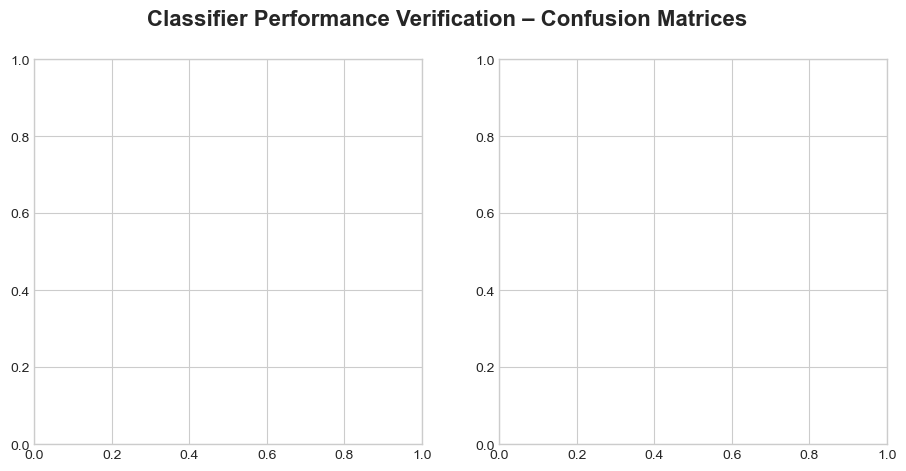

In [1]:
# # QSPR Model Verification and Visualization
# 
# This notebook loads a previously trained model and its corresponding training/test data to:
# 1.  Verify the model's performance by recalculating key metrics.
# 2.  Generate a publication-quality scatter plot of observed vs. predicted values.
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("Libraries imported successfully.")

# ===================================================================
# CONFIGURATION: Specify file paths
# ===================================================================
model_path = './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl'
train_data_path = './Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_train_data.parquet'
test_data_path = './Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_test_data.parquet'

# Load the model
model = joblib.load(model_path)
print(f" Model loaded successfully from:\n  {model_path}\n")

# Load the datasets
train_df = pd.read_parquet(train_data_path)
test_df = pd.read_parquet(test_data_path)
print(f" Training data loaded successfully from:\n  {train_data_path} (shape: {train_df.shape})")
print(f" Test data loaded successfully from:\n  {test_data_path} (shape: {test_df.shape})")
# ## Prepare Data and Make Predictions

# ===================================================================
# DATA PREPARATION AND PREDICTION
# ===================================================================
# Separate features (X) and target (y)
TARGET_COLUMN = 'epox_cla'

X_train = train_df.drop(columns=[TARGET_COLUMN])
X_train = X_train[list(train_df.iloc[:, :-1].columns)]
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
X_test = X_test[list(train_df.iloc[:, :-1].columns)]
y_test = test_df[TARGET_COLUMN]

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# Predicted probabilities (assumes binary classification and predict_proba support)
if hasattr(model, "predict_proba") and len(np.unique(y_train)) == 2:
    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_proba_test = model.predict_proba(X_test)[:, 1]
else:
    y_proba_train = None
    y_proba_test = None

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# ===================================================================
# PERFORMANCE VERIFICATION
# ===================================================================
def summarize_performance(y_true, y_pred, split_name=""):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\n[{split_name}]")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Balanced Accuracy : {bal_acc:.4f}")
    print(f"  F1 (macro)        : {f1_macro:.4f}")
    return acc, bal_acc, f1_macro

train_acc, train_bal_acc, train_f1 = summarize_performance(y_train, y_pred_train, "TRAIN")
test_acc, test_bal_acc, test_f1 = summarize_performance(y_test, y_pred_test, "TEST")

print("\n╔══════════════════════╦═════════════╦═════════════╗")
print("║       Metric         ║  Train Set  ║   Test Set  ║")
print("╠══════════════════════╬═════════════╬═════════════╣")
print(f"║ Accuracy             ║  {train_acc:9.4f}  ║  {test_acc:9.4f}  ║")
print(f"║ Balanced Accuracy    ║  {train_bal_acc:9.4f}  ║  {test_bal_acc:9.4f}  ║")
print(f"║ F1 (macro)           ║  {train_f1:9.4f}  ║  {test_f1:9.4f}  ║")
print("╚══════════════════════╩═════════════╩═════════════╝")

# Optional: detailed text report for test set
print("\nClassification report (TEST):")
print(classification_report(y_test, y_pred_test, digits=3))

# ===================================================================
# CONFUSION MATRICES (TRAIN & TEST)
# ===================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(11, 5.0))
fig.suptitle('Classifier Performance Verification – Confusion Matrices', fontsize=16, fontweight='bold')

# Class labels (sorted for consistent ordering)
labels = np.sort(train_df[TARGET_COLUMN].unique())




def plot_confusion_matrix(
    y_true,
    y_pred,
    labels,
    title,
    file_name,
    cmap,
    figsize=(4.5, 4),   # dobry rozmiar podobny do regresji
    text_size=12
):
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        cbar=False,
        annot_kws={"size": text_size},
        ax=ax
    )

    ax.set_title(title, fontsize=text_size + 2, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted label', fontsize=text_size)
    ax.set_ylabel('True label', fontsize=text_size)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels, rotation=0)
    ax.tick_params(axis='both', labelsize=text_size)

    plt.tight_layout(pad=1.0)

    plt.savefig(file_name, format='svg', bbox_inches='tight')
    plt.close()








# --- Training Confusion Matrix (osobny SVG) ---
plot_confusion_matrix(
    y_train, y_pred_train,
    labels,
    title='Training Set',
    file_name='classifier_confusion_matrix_train.svg',
    cmap='Blues',
    # ustawienia podobne do wykresu regresji:
    figsize=(4.5, 4),
    text_size=12
)

# --- Test Confusion Matrix (osobny SVG) ---
plot_confusion_matrix(
    y_test, y_pred_test,
    labels,
    title='Test Set',
    file_name='classifier_confusion_matrix_test.svg',
    cmap='Reds',
    figsize=(4.5, 4),
    text_size=12
)

print(" Figure saved as 'classifier_confusion_matrices.svg'")